# 01 — Micrograd: Neural Networks & Backpropagation from Scratch

**Source:** [Karpathy - Zero to Hero, Episode 1](https://www.youtube.com/watch?v=VMj-3S1tku0)  
**Topic:** Building micrograd — a tiny scalar-valued autograd engine  
**Goal:** Understand forward pass, backward pass, and how gradients flow through a computational graph

In [1]:
import sys
!{sys.executable} -m pip install micrograd --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Numerous possible operations supported

"""
from micrograd.engine import value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a + b + b**3
c += c + 1
c += 1 + c + (-a)
d += 3 * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of the FORWARD PASS
g.backward()           # APPLIES CHAIN RULE FROM CALCULUS
print(a'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(b'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db
"""

"\nfrom micrograd.engine import value\n\na = Value(-4.0)\nb = Value(2.0)\nc = a + b\nd = a + b + b**3\nc += c + 1\nc += 1 + c + (-a)\nd += 3 * 2 + (b + a).relu()\nd += 3 * d + (b - a).relu()\ne = c - d\nf = e**2\ng = f / 2.0\ng += 10.0 / f\nprint(f'{g.data:.4f}') # prints 24.7041, the outcome of the FORWARD PASS\ng.backward()           # APPLIES CHAIN RULE FROM CALCULUS\nprint(a'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da\nprint(b'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db\n"

```
Neural networks are a mathematical expression.
They take input data, take weights of the NN as input, output is predictions or 'loss function'...
Backpropagation is general. Cares about arbitrary mathematical expressions.
micrograd is a scalar valued autograd engine. Working on the level of individual scalars...
```

# Derivatives
Basic understanding:

In [3]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

/home/merlin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
def f(x):
  return 3*x**2 - 4*x + 5

In [5]:
f(3.0)

20.0

In [6]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [7]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

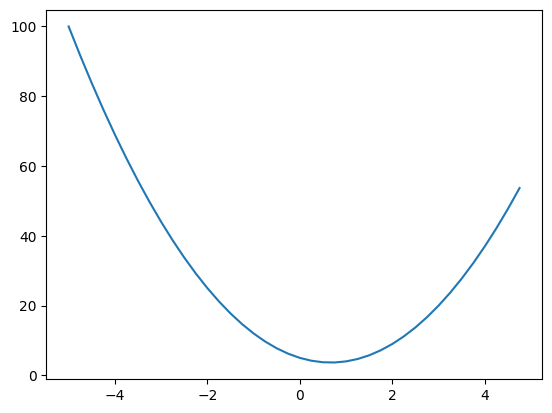

In [8]:
plt.plot(xs, ys)

```
Derivatives measure the rate of change of a function at any given point, specifically, how much the output changes in response to a tiny change in the input.
Geometrically, it gives the slope of the tangent line to the curve at that point.

For a function like f(x) = 3x² - 4x + 5, the derivative tells you: at any value of x, how steeply is the function rising or falling?
A positive derivative means the function is increasing at that point.
A negative derivative means the function is decreasing at that point.
Zero means flat point.
A peak, a valley, or an inflection

During training, a neural network is trying to minimize a loss function; a measure of how wrong its predictions are.
To do that, it needs to know:
for each weight in the network, if I nudge this weight slightly, does the loss go up or down, and by how much? (Derivative)

Backpropagation is just the chain rule from calculus applied repeatedly through the network to compute those derivatives efficiently for every single weight simultaneously.

g.backward() is computing derivatives.
.grad values it produces are the derivatives of the loss with respect to each value in the computational graph.
```

In [9]:
h = 0.001
x = 3.0
f(x + h)

20.014003000000002

In [10]:
f(x + h) - f(x)

0.01400300000000243

This is how much the function responded to the nudge. (Rise)

In [11]:
(f(x + h) - f(x))/h

14.00300000000243

Normalized by rise / run to get the slope.
Decreased `h` converges to the exact amount.

In [12]:
h = 0.000001
x = 3.0
(f(x + h) - f(x))/h

14.000003002223593

Too many zeros in `h` will begin to generate incorrect answers due to the use of floating point arithmetic.  
Representation of the numbers in computer memory is finite.

In [13]:
h = 0.00000001
x = -3.0
(f(x + h) - f(x))/h

-22.00000039920269

Slope is negative now.

In [14]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h

0.0

Slope is zero now. At this point, nudging in a positive direction, the function stays practically the same.

In [15]:
# Increased complexity

a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


Function of 3 scalar inputs, d variable output.  
To observe the derivatus:

In [16]:
h = 0.0001

# INPUTS
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2) # d2 is bumping by h, (a += h)
print('slope', (d2 - d1)/h)    # d2 - d1 is how much the function increased when bumping input by variable amount. Normalized by h to get slope.


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


Since `b` is a negative number, the nudge decreases the `d2` output.

In [17]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)  # What is the influence of b out output d

d1 4.0
d2 4.0002
slope 2.0000000000042206


Bumping `a` in a positive direction now, because `a` is positive, value is *added* to d.  
Output is 2, because `d` / `db` gives `a`.
And value of `a` is 2.

In [18]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)  # What is the influence of b out output d

d1 4.0
d2 4.0001
slope 0.9999999999976694


Bumping `c`, `a*b` is unaffected, and now `c` becomes slightly higher.  
Simply adding `c`, makes function slightly higher.  
Higher by the *exact* amount added to `c`.  
Output `slope` is the rate of increase for `d` when scaling `c`.

---

NNs are massive expressions.  
Need data structures to maintain the expressions.  

In [73]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

# Added later, addition

    def __add__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data + other.data, (self, other), '+')
        
      def _backward():
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad
      out._backward = _backward
        
      return out

    def __radd__(self, other):
      return self + other

# Multiplication

    def __mul__(self, other):
      other = other if isinstance(other, Value) else Value(other)
      out = Value(self.data * other.data, (self, other), '*')
        
      def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
      out._backward = _backward
        
      return out

    def __pow__(self, other):
      assert isinstance(other, (int, float)), "only supporting int/float powers for now.."
      out = Value(self.data**other, (self,), f'**{other}')

      def _backward():
          self.grad += other * (self.data ** (other - 1)) * out.grad
      out._backward = _backward

      return out
    
    def __rmul__(self, other):
      return self * other

    def __truediv__(self, other):
      return self * other**-1

    def __rtruediv__(self, other):
      return other * self**-1

    def __neg__(self):
      return self * -1

    def __sub__(self, other):
      return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
      x = self.data
      out = Value(math.exp(x), (self, ), 'exp')

      def _backward():
        self.grad += out.data * out.grad
      out._backward = _backward

      return out

    
    def backward(self):
       
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
          node._backward()


Class `Value` takes a single scalar value, which it wraps and tracks.

In [20]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [21]:
# Division reshuffle

a / b
a * (1/b)
a * (b**-1)

Value(data=0.5)

Python internally uses `__repr__` to return the string.  
When typing something like `xs` in a cell, Python calls `xs.__repr__()` behind the scenes to produce the visible output.  
Same when inspecting an object in a debugger or seeing it printed in an error traceback.  

Distinction from `__str__`:  
    - `__repr__`; meant to be unambiguous and developer-facing. Ideally should look like valid Python that could recreate the object.  
    - `__str__` ; meant to be readable and user-facing, like a clean print output.

*In this context:*  
When building micrograd and inspecting the computational graph, withut `__repr__`, you would see something useless like:  
`<__main__.Value_object at 0x7f3c2a1b4d90>`.  
By defining `__repr__` to return something like `Value(data=2.0)`, every time you inspect a node in the graph you immediately see the actual scalar value it holds. Essential for debugging a NN that's being built from scratch.

A small concept that makes the difference between a usable and unusable development experience when introspecting objects interactively.

In [22]:
# Running the addition function

a = Value(2.0)
b = Value(-3.0)
a + b

Value(data=-1.0)

Using the dunder methods to define *operators* for the objects within the class.  
Under the hood: `a.__add__(b)` is called.  
`a` = `self`  
`b` = `other`

In [23]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'

# Adding f variable after label='' implementation
f = Value(-2.0, label='f')

L = d * f; L.label='L'   # L now becomes the output of the graph
L

Value(data=-8.0)

Under the hood:  
`(a.__mul__(b)).__add__(c)`

Before `children=()` empty tuple value in `__init__`:  
Currently, missing the connective 'tissue' of this expression.  
We need to keep pointers about what values produce what other values.  

`_children()` is a tuple, but maintained within the class it is a set.

Now, when creating a value through addition or multiplication, we will feed in the children of the value, `self, other`.

In [24]:
d = a*b + c
d._prev

{Value(data=-6.0), Value(data=10.0)}

Now, we have the children of the values, `-6.0` and `10.0`.  
The value resulting from `a*b` and `c`, respectively.

Now that we know the children, we also need to know the operation that created the value(s).  
Introduce `_op=''`, empty set for leafs.

In [25]:
d = a*b + c
d._op

'+'

`d` was produced as an addition of the two values.

---

In [26]:
from graphviz import Digraph
from micrograd.engine import Value

The expressions will become exponentially larger.  
Need a way to visualize the expressions being built.  
(copy + paste from micrograd repo, graph output unavailable):

In [27]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

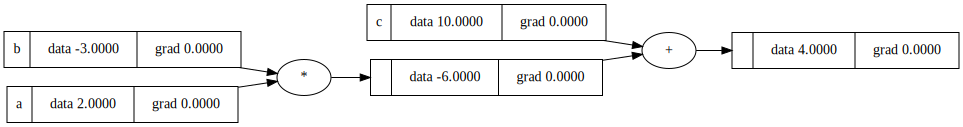

In [28]:
draw_dot(d)

Discrepancy in build at this point, `draw_dot(d)` throws error instead of producing the graph expected.  
Built through `graphviz` API.

Back in the class `Value`, defining `label=''` within the parameters for the purpose of labelling this graph.  
Not applicable.

## GRAPH DESCRIPTION  
*Since unavailable, a textual description:*  

At this point, we are able to build out mathematical expressions using only + and * so far.  
Scalar valued, we can do a forward pass and build out a mathematical expression with multiple inputs; 'a', 'b', 'c', 'f'  
These go into a mathematical expression that produces a single output, now 'L'.  
The graph would be visualizing the forward pass.  
Output of the forward pass is Value(data=-8.0)

## BACKPROPAGATION

In backpropagation, we begin at the end, or 'L', and reverse, calculating the gradient along all intermediate values.  
For every single value, we compute the derivative of that node with respect to 'L'.
The derivative of 'L' with respect to 'L' is 1.
The derivative of 'L' with respect to 'f' ...
The derivative of 'L' with respect to 'd' ...
The derivative of 'L' with respect to 'c' ...
The derivative of 'L' with respect to 'e' ...
The derivative of 'L' with respect to 'b' ...
The derivative of 'L' with respect to 'a' ...

In the context of NNs, we are interested in the derivative of the loss function, 'L', with respect to the weights of a NN.  
Variables will eventually represent the weights of a neural net.  
We will need to know how weights are impacting the loss function.  
Interested in the derivative of the output, with respect to some of its leaf nodes, i.e. the weights of the NN.  
Other leaf nodes will be data itself.  

We usually do not want or to use the derivative of the loss function with respect to data, since the data is fixed.  
Weights will be iterated on using gradient information.

## ADDING

Create a variable inside Value class that maintains the derivative of 'L' with respect to the variable.

```
L = d * f

dL/dd = ? `f`

(f(x+h)-f(x))/h
(d+h)*f - d*f)/h
(d*f + h*f - d*f) / h
(h*f)/h
f
```

In [29]:
L.grad = 1.0    # Output for the graph (unavailable still)

In [32]:
def lol():

    h = 0.0001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    a = Value(2.0 + h, label='a')    # Measuring the derivative of L with respect to a with + h
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data
    
    print((L2 - L1)/h)   # L2 - L1 is how much L changed, the normalized by h (rise over run)

lol()

6.000000000021544


Here, we caluclated the derivative of `L` with respect to `a`.

Verifying each variable along with graph cells, e.g., [ d | data 4.000 | grad -2.0000 ]  
*Inline gradient check*.

Gradient check is when we are deriving backpropagation and getting derivative with respect to all intermediate results.

Numerical gradient is estimating using small step size.

# CRUX OF BACKPROPAGATION

dL / dc
dL / de

Derivative `L` with respect to `c`.

If we know the impact that `c` is having on `d`, and we know the impact that `d` is having on `L`, we can discover the impact that `c` is having directly on `L`.

dd / dc  - differentiating c + e with respect to c gives 1.0 here.
dd / de = 1.0
d = c + e

d = c + e

(f(x+h) - f(x)) / h

((c+h + e) - (c + e)) / h    or    (c + h + e - c - e) / h  
c - c cancels.  
e - e cancels.  
Left with h/h  
= 1.0

In order to piece together the derivative information from one node's impact on the next, the *chain rule* must be applied to carry the information from the `c` node all the way to the `L` node.

*Chain Rule:*
"If a variable *z* depends on the variable *y*, which itself depends on the variable *x* (that is, *y* and *z* are the dependent variables), then *z* depends on *x* as well, via the intermediate variable *y*.

The chain rule states that knowing the instantaneous rate of change of *z* relative to *y* and that of *y* relative to *x* allows one to calculate the instantaneous rate of change of *z* relative to *x* as the **product of the two rates of change**.

"If a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car travels **2 x 4 = 8** times as fast as the man"

```
dd / dc = 1.0
dd / de = 1.0
d = c + e

WANT:
dL / dc = (dL / dd) * (dd / dc)    # CHAIN RULE

KNOW
dL / dd
dd / dc
```

**Backpropagation is a recursive application of chain rule backwards through the computational graph.**

### NOTE: Graph has been implemented at this point in time.

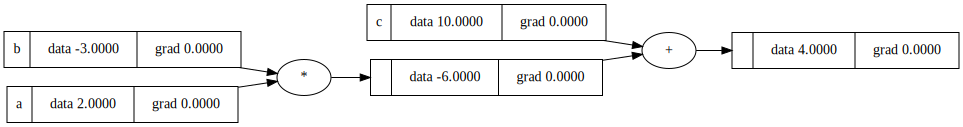

In [33]:
draw_dot(d)

---

# NEURON BACKPROPAGATION

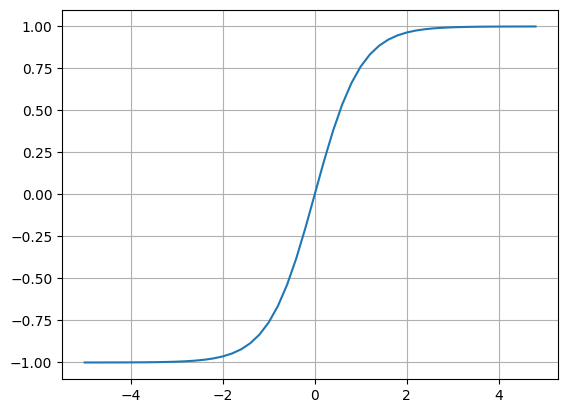

In [34]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

"Squashing function" / "Activation function"

Inputs get 'squashed.'  
Moving positively, the function plateaus at 1.  
Moving negatively, the function plateaus at -1.  
*"Smooth cap."*

The output of a neuron is the activation function applied to the dot product of the weights and inputs.

*"The forward pass of a neuron is essentially a dot product of inputs and weights, plus a bias; output = w * x + b"*

In [35]:
# inputs x1,x2
# 2-dimensional neuron, 2 inputs come in

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1.w2
# weights are the synaptic strength for each input

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron

b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
# draw_dot(o)

```
Hyperbolic functions are directly tied in because the most common neural network activation functions are either hyperbolic functions or closely related to them.

Core hyperbolic functions:
sinh(x) = (eˣ - e⁻ˣ) / 2
cosh(x) = (eˣ + e⁻ˣ) / 2
tanh(x) = sinh(x) / cosh(x) = (eˣ - e⁻ˣ) / (eˣ + e⁻ˣ)

Neural network connection:
'tanh' is a classic activation function. It takes the dot product output of a neuron (w*x+b) and squashes it into the range (-1,1), introducing the non-linearity that lets networks learn complex patterns

'sigmoid', another common activation, is closely related:
σ(x) = 1 / (1 + e⁻ˣ)

..and can be expressed in terms of tanh:
σ(x) = (tanh(x/2) + 1) / 2

Why this matters for backprop: 
The derivatives of hyperbolic functions are clean, which is why they're friendly for backpropagation:
d/dx tanh(x) = 1 - tanh²(x)
d/dx sinh(x) = cosh(x)
d/dx cosh(x) = sinh(x)

When micrograd calls '.backward()' through a tanh activation, it's computing 1 - tanh²(x) at that node - a very cheap operation since 'tanh(x)' is already computed in the forward pass.

ReLU sidesteps all of this with a simpler derivative, therefore popular in modern deep learning.

What ReLU is:
ReLU(x) = max(0, x)

If the input is positive, pass it through unchanged.
If the input is negative, output 0.

Equally simple derivative
d/dx ReLU(x) = 1 if x > 0
               0 if x < 0

The backward pass is just a switch. No exponentials, no division, simply: "did this neuron fire or not?"

Why it matters over tanh/sigmoid:
tanh and sigmoid both suffer from 'vanishing gradient problem.' In deep networks, their gradients get multiplied together repeatedly during backprop and shrink toward zero, making early layers learn extremely slowly.
ReLU's  gradient is either 0 or 1, so it doesn't crush the signal in the same way.

Dying ReLU:
If a neuron's input is always negative, it always outputs 0, its gradient is always 0, and it never updates.
That neuron is "dead."
Varients like Leaky ReLU and GELU were designed to address this.
```

## Backpropagation

What is the derivative of `o` with respect to all input nodes?  
In typical NN setting, we care most about the derivative of the weight nodes.  
This is also one single neuron, a piece of a larger puzzle.  
Evenetually there is a loss function that measures the accuracy of the NN.  
We're backpropagating with respect to that accuracy, trying to increase it.

In [36]:
o.backward()

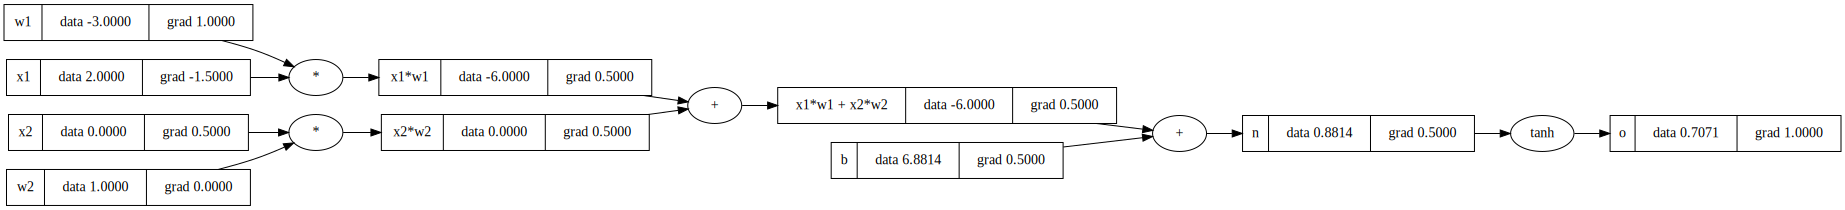

In [37]:
draw_dot(o)

---

In [38]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
  node._backward()

In [39]:
# This ordering of graphs can be achieved with toplogical sort

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

---

In [ ]:
# CODED BACKPROP

In [40]:
o.grad = 1.0

In [41]:
o._backward()    # n.grad now shows 0.5

In [42]:
n._backward()    # n._backward routes the gradient forward via + operator

In [43]:
b._backward()    # nothing will happen, b is a leaf node

In [44]:
x1w1x2w2._backward()    # futher 0.5 routing

In [45]:
x2w2._backward()
x1w1._backward()

---

In [ ]:
# MANUAL BACKPROP

In [46]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [47]:
# Local chain rule

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [48]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [49]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [50]:
n.grad = 0.5

In [51]:
o.grad = 1.0

In [52]:
o.data

0.7071067811865476

In [ ]:
# To backprop through tanh, we need the local derivative of tanh.
# o = tanh(n)
# What is do / dn?
# do/dn = 1 - o²

In [53]:
1 - o.data**2

0.4999999999999999

Backprop from `n` node through the `+` operator means simple distribution of grad. The 0.5 value carries over without complication.  
A + is a distributer of gradient.  
The local derivative of the operation is 1 for every 1 of its nodes.

`x1w1x2w2` and `b` inherit the 0.5 value.

And with another + operator in the backprop sequence, 0.5 is once again carried over.

If we want the output of the neuron to increase, the influence of the weighted input expressions is positive on the output.  
Positive contribution to output.

---

# CODED BACKPROP backward() BUG FIX

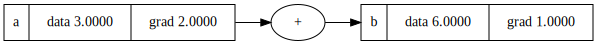

In [54]:
a = Value(3.0, label='a')
b = a + a    ; b.label = 'b'
b.backward()
draw_dot(b)

The gradient for `a`, `1.0000`, is not actually accurate.  
Derivative of `b` with respect to `a` should be `2`, 1 + 1.  
Instead, the current `Value` class code is overriding the gradient, keeping it at 1 constantly.

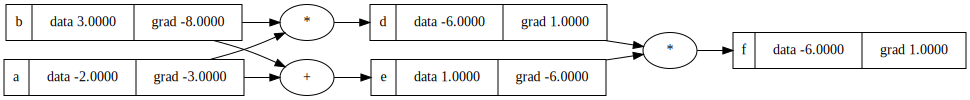

In [55]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

There will be an issue any time a variable is used more than once.  
During backprop, e.g., `e` will call back and write gradients to `a` and `b` respectively.  
Then when `d` calculates and writes to `a` and `b`, it overwrites the gradients with its own values.  

The solution, per the multivariable case of chain rule, we have to accumulate the gradients. They must add. `+=`

---

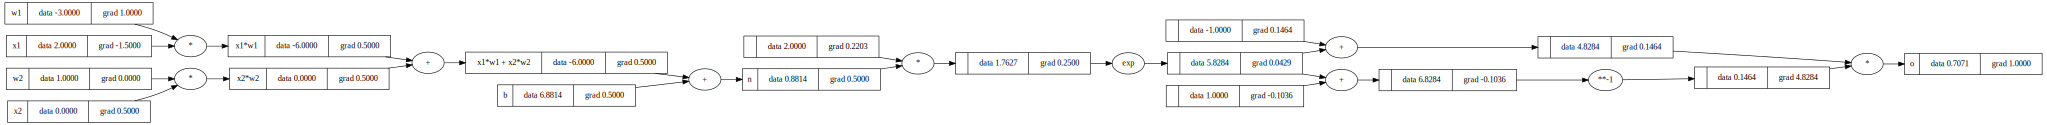

In [56]:
# inputs x1,x2
# 2-dimensional neuron, 2 inputs come in

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1.w2
# weights are the synaptic strength for each input

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron

b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---
o.label = 'o'
o.backward()
draw_dot(o)

---

# PYTORCH IMPLEMENTATION

Micrograd is a scalar valued engine.  
In PyTorch, everything is based on tensors.  
Tensors are N-dimensional arrays of scalars.

In [57]:
import torch
print(torch.__version__)

2.12.0+cu130


In [58]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [59]:
torch.Tensor([[1, 2, 3], [4, 5, 6,]]).shape

torch.Size([2, 3])

Default value of tensors use float32, single precision.  
.double() typecast keeps values consistent.  
PyTorch assumes leaf nodes do not require gradients. .requires_grad = True forces gradients.  
First portion constructs scalar valued 1-element tensors.  
.item() takes a single tensor and returns the element, stripping the tensor.  

In [60]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [61]:
o.item()

0.7071066904050358

In [62]:
x2.grad

tensor([0.5000], dtype=torch.float64)

In [63]:
x2.grad.item()

0.5000001283844369

---

# NEURAL NET CONSTRUCTION

In [79]:

class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * b + x
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len (outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [122]:
x = [2.0, 3.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.8729727769492367)

In [82]:
n.parameters()

[Value(data=-0.3127177916778785),
 Value(data=0.6067465215810763),
 Value(data=-0.8261787770146627),
 Value(data=0.1864124848614339),
 Value(data=0.8069466392836382),
 Value(data=0.9432508299423179),
 Value(data=0.26137603220600014),
 Value(data=0.9897174502849104),
 Value(data=-0.09836689320232828),
 Value(data=-0.25015016407104484),
 Value(data=-0.47627027255040244),
 Value(data=-0.971009556110269),
 Value(data=0.30333236005301845),
 Value(data=0.8385628404868746),
 Value(data=-0.784669171913938),
 Value(data=0.1595866087262967),
 Value(data=0.9487493104364009),
 Value(data=-0.4830485218575109),
 Value(data=0.32470941915718554),
 Value(data=0.48711690554659004),
 Value(data=-0.23220059248455915),
 Value(data=0.0928080517044847),
 Value(data=-0.07427338518774507),
 Value(data=-0.7436223222458995),
 Value(data=0.544807407318082),
 Value(data=0.128122259218181),
 Value(data=-0.21820457767302726),
 Value(data=-0.962119781839577),
 Value(data=-0.30291348343754265),
 Value(data=0.993517593

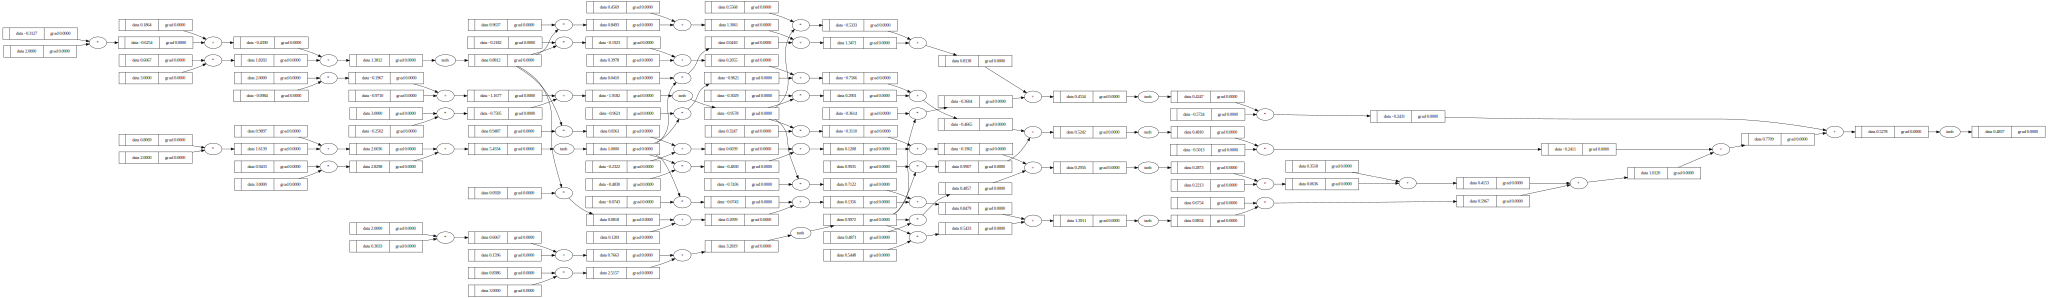

In [83]:
draw_dot(n(x))

---

In [118]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]    # desired targets

With the outputs as reference, we can adjust the weights accordingly, pushing higher or lower values to get closer to 1 or -1.

How do we tune the weights? Calculate a single number that measures the total performance of the NN.  
Loss. (Mean squared error loss)

In [85]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.418488159219036)

In [98]:
# Comparison with previous output, after implementing gradient descent concept
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=3.358553492708543)

For each, we take the prediction and ground truth, subtract, and square.  
Now we want to minimize the loss.  
If loss is low, every prediction is equal to target.  
The greater the value of loss, the worse the NN predictions.

In [96]:
loss.backward()

In [87]:
n.layers[0].neurons[0].w[0].grad

-0.2783818086319959

This gradient on this particular weight, on this particular neuron, on this particular layer is negative.  
Therefore the influence on loss is negative.  
Increasing this particular weight would make the loss go down.  

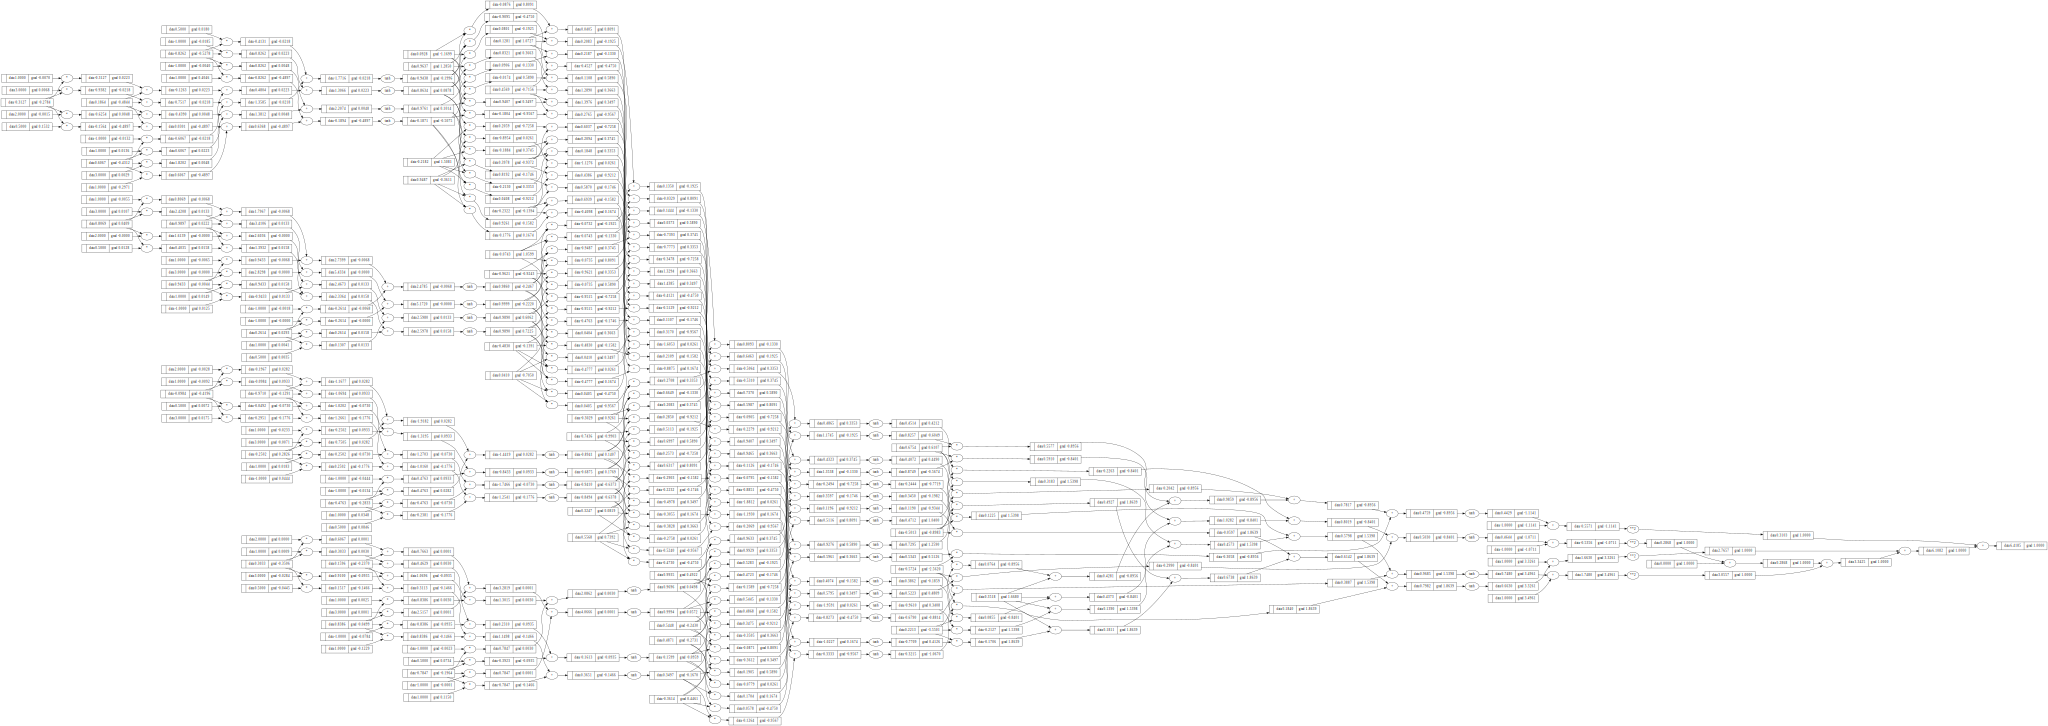

In [88]:
draw_dot(loss)

In [116]:
n.layers[0].neurons[0].w[0].data

0.04094517142161032

In [97]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In gradient descent, we think of the gradient as a vector pointing in the direction of increased loss.  
We modify p.data by a small step size in the direction of the gradient.

In [91]:
n.layers[0].neurons[0].w[0].data

-0.30993397359155855

In [117]:
# Forward pass

ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.213512223779876e-29)

In [101]:
# Backward pass

loss.backward()

In [102]:
# Update

for p in n.parameters():
  p.data += -0.01 * p.grad

Forward pass -> Backward pass -> Update

Reiterate this until target achieved.  

Stepping too far can distabilize the training; overconfidence.

If the learning rate is too low, it takes too long to converge.  
If too high, it's unstable and you can explode the loss.

In [119]:
ypred

[Value(data=1.0),
 Value(data=-1.0),
 Value(data=-1.0),
 Value(data=0.9999999999999921)]

In [113]:
n.parameters()

[Value(data=0.04094517142161032),
 Value(data=0.8349666954245261),
 Value(data=-1.5741238612498076),
 Value(data=0.3339585461914162),
 Value(data=0.5811741689349056),
 Value(data=0.972708219597512),
 Value(data=0.15105795059163912),
 Value(data=0.8765566883138286),
 Value(data=3.80646687694824),
 Value(data=-1.6092914443665542),
 Value(data=0.879798212202656),
 Value(data=0.5138787115642752),
 Value(data=-0.4376442168100957),
 Value(data=0.03785167496086883),
 Value(data=-1.5414341523317059),
 Value(data=-0.7039010662924408),
 Value(data=5.784301074811176),
 Value(data=0.882542990220895),
 Value(data=-0.2744417290562404),
 Value(data=3.9533975084632327),
 Value(data=1.1321421576246387),
 Value(data=9.030903071820248),
 Value(data=-8.665704950161555),
 Value(data=7.0800029025293805),
 Value(data=1.9858280215581363),
 Value(data=-8.567994355127059),
 Value(data=-9.626586930442866),
 Value(data=5.160173655998057),
 Value(data=-6.236577161370166),
 Value(data=-1.8143009287089784),
 Value(d

---

# LOOPING

In [143]:
# Forward pass

for k in range(20):

  # Forward
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # Backward
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # Update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)


0 0.004034095592582199
1 0.0040108515308050685
2 0.003987861750811944
3 0.003965122172209082
4 0.003942628800657747
5 0.003920377725630376
6 0.0038983651182364553
7 0.003876587229115272
8 0.003855040386393587
9 0.003833720993705358
10 0.0038126255282719046
11 0.0037917505390400296
12 0.003771092644876137
13 0.0037506485328144164
14 0.0037304149563573462
15 0.00371038873382635
16 0.0036905667467614467
17 0.0036709459383675795
18 0.0036515233120065576
19 0.003632295929732833


In [144]:
ypred

[Value(data=0.9744041064650484),
 Value(data=-0.9653934939209254),
 Value(data=-0.9750413185106794),
 Value(data=0.9659911758628165)]

---

# SUMMARY

Neural Networks are mathematical expressions that take data and weights as parameters for input.  
A mathematical expression for forward pass, followed by a loss function, and the loss function tries to measure accuracy for predictions.  
Usually, loss is low when predictions are matching targets, or when the network is behaving well.  
We manipulate the loss function so when loss is low, the network is doing what's desired on the problem.  
Then use backpropagation to obtain the gradient, and tune the parameters to decrease loss locally.  
Then we iterate that process many times in gradient descent.  
Follow the gradient information that minimizes loss, and the loss is arranged so that when minimized, the network does what is desired.  

